# Label Frequency Skew Analysis — Impact on GliZNet Embedding Quality

**Core concern:** GliZNet uses a **single shared DeBERTa encoder** for both text and labels in one forward pass. Labels with ~7,000 appearances contribute gradient updates to the shared encoder on nearly every training step, while the median label (freq=5) sees updates in ~0.3% of batches. This 1,400× frequency ratio means high-frequency label tokens may **hijack the shared representation space**, distorting the similarity structure between rare labels and breaking zero-shot generalization.

**Architecture reminder:**
```
[CLS] text_tokens [SEP] label1 [LAB] label2 [LAB] ... → DeBERTa → L2-norm → Bilinear(768,768,1) → logit
```
All label tokens pass through the same encoder weights. The bilinear head (590K params) absorbs some specialization, but the encoder (184M params) receives the lion's share of gradient signal.

This notebook quantifies the risk and tests mitigations.

## 1. Load Data & Frequency Distribution

In [1]:
import json, pathlib
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

DATA_PATH = pathlib.Path("../../generate-gliznet-data/data/wikipedia_synthetic.jsonl")
TAXONOMY_PATH = pathlib.Path("../data/pretrain/label_taxonomy.json")

# Load rows
rows = [json.loads(l) for l in DATA_PATH.read_text().splitlines() if l.strip()]
print(f"Loaded {len(rows):,} rows")

# Load taxonomy
taxonomy = json.loads(TAXONOMY_PATH.read_text())
taxonomy_labels = {lbl for cl in taxonomy["clusters"].values() for lbl in cl["labels"]}
cluster_map = {lbl: name for name, cl in taxonomy["clusters"].items() for lbl in cl["labels"]}
print(f"Taxonomy: {len(taxonomy_labels):,} labels in {len(taxonomy['clusters'])} clusters")

Loaded 124,085 rows
Taxonomy: 1,952 labels in 99 clusters


In [4]:
# Count total label appearances (pos + neg roles)
total_freq = Counter()
pos_freq = Counter()
neg_freq = Counter()

for r in rows:
    for lbl in r.get("labels", []):
        total_freq[lbl] += 1
        pos_freq[lbl] += 1
    for lbl in r.get("not_labels", []):
        total_freq[lbl] += 1
        neg_freq[lbl] += 1

freqs = np.array(sorted(total_freq.values(), reverse=True))
unique_labels = set(total_freq.keys())

print(f"Unique labels: {len(unique_labels):,}")
print(f"Max freq:      {freqs[0]:,}")
print(f"P99 freq:      {int(np.percentile(freqs, 99)):,}")
print(f"P95 freq:      {int(np.percentile(freqs, 95)):,}")
print(f"P75 freq:      {int(np.percentile(freqs, 75)):,}")
print(f"Median freq:   {int(np.median(freqs)):,}")
print(f"P25 freq:      {int(np.percentile(freqs, 25)):,}")
print(f"Mean freq:     {np.mean(freqs):.1f}")
print(f"Singletons:    {(freqs == 1).sum():,} ({(freqs == 1).sum()/len(freqs)*100:.1f}%)")
print(f"Max/Median:    {freqs[0]/np.median(freqs):.0f}×")

Unique labels: 10,714
Max freq:      9,226
P99 freq:      2,722
P95 freq:      861
P75 freq:      11
Median freq:   5
P25 freq:      1
Mean freq:     140.4
Singletons:    3,332 (31.1%)
Max/Median:    1845×


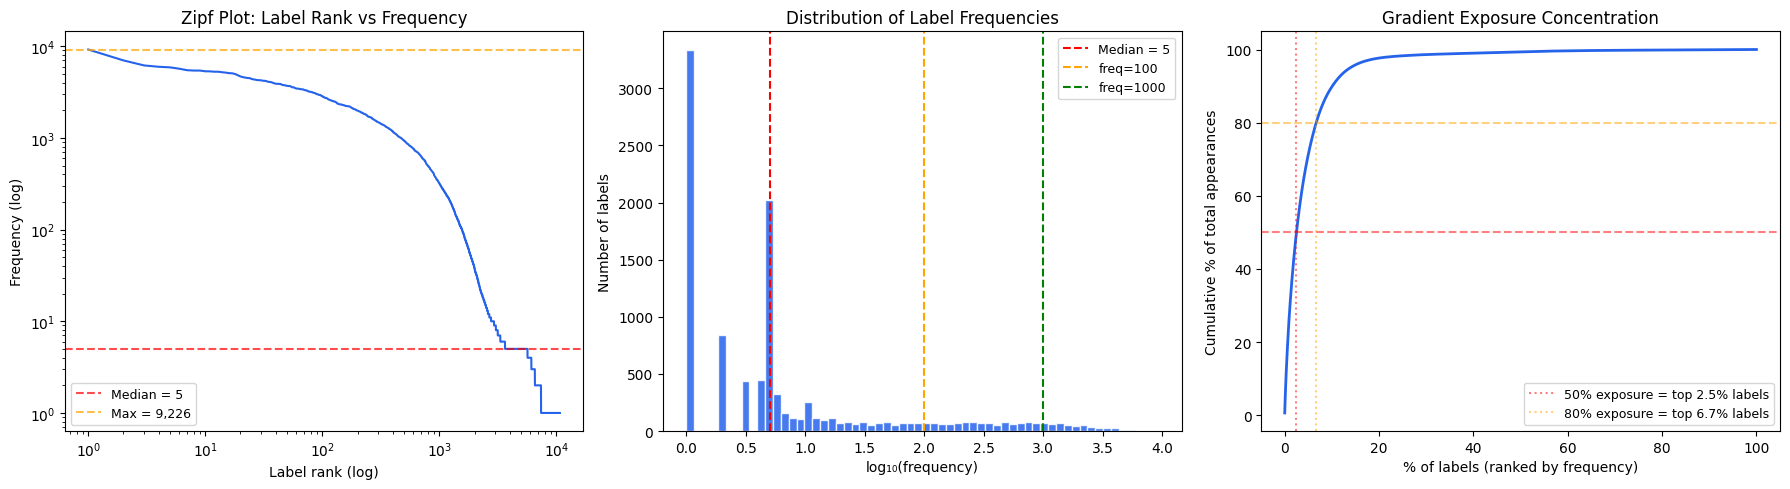


→ Top 2.5% of labels account for 50% of all gradient exposure
→ Top 6.7% of labels account for 80% of all gradient exposure
→ Bottom 50% of labels account for only 0.6% of exposure


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Log-log rank-frequency (Zipf plot)
ax = axes[0]
ranks = np.arange(1, len(freqs) + 1)
ax.loglog(ranks, freqs, linewidth=1.5, color="#2563eb")
ax.axhline(np.median(freqs), color="red", ls="--", alpha=0.7, label=f"Median = {int(np.median(freqs))}")
ax.axhline(freqs[0], color="orange", ls="--", alpha=0.7, label=f"Max = {freqs[0]:,}")
ax.set_xlabel("Label rank (log)")
ax.set_ylabel("Frequency (log)")
ax.set_title("Zipf Plot: Label Rank vs Frequency")
ax.legend(fontsize=9)

# 2) Histogram of log-frequencies
ax = axes[1]
ax.hist(np.log10(freqs), bins=60, color="#2563eb", edgecolor="white", alpha=0.85)
ax.axvline(np.log10(np.median(freqs)), color="red", ls="--", label=f"Median = {int(np.median(freqs))}")
ax.axvline(np.log10(100), color="orange", ls="--", label="freq=100")
ax.axvline(np.log10(1000), color="green", ls="--", label="freq=1000")
ax.set_xlabel("log₁₀(frequency)")
ax.set_ylabel("Number of labels")
ax.set_title("Distribution of Label Frequencies")
ax.legend(fontsize=9)

# 3) Cumulative share of gradient exposure
cumulative_share = np.cumsum(freqs) / freqs.sum()
ax = axes[2]
ax.plot(ranks / len(freqs) * 100, cumulative_share * 100, linewidth=2, color="#2563eb")
ax.axhline(50, color="red", ls="--", alpha=0.5)
ax.axhline(80, color="orange", ls="--", alpha=0.5)
pct_50 = np.searchsorted(cumulative_share, 0.5) / len(freqs) * 100
pct_80 = np.searchsorted(cumulative_share, 0.8) / len(freqs) * 100
ax.axvline(pct_50, color="red", ls=":", alpha=0.5, label=f"50% exposure = top {pct_50:.1f}% labels")
ax.axvline(pct_80, color="orange", ls=":", alpha=0.5, label=f"80% exposure = top {pct_80:.1f}% labels")
ax.set_xlabel("% of labels (ranked by frequency)")
ax.set_ylabel("Cumulative % of total appearances")
ax.set_title("Gradient Exposure Concentration")
ax.legend(fontsize=9, loc="lower right")

plt.tight_layout()
plt.show()

print(f"\n→ Top {pct_50:.1f}% of labels account for 50% of all gradient exposure")
print(f"→ Top {pct_80:.1f}% of labels account for 80% of all gradient exposure")
print(f"→ Bottom 50% of labels account for only {(1 - cumulative_share[len(freqs)//2]) * 100:.1f}% of exposure")

In [6]:
# Top 30 most frequent labels — these dominate the encoder gradient
top30 = total_freq.most_common(30)
df_top = pd.DataFrame(top30, columns=["label", "total_freq"])
df_top["pos_freq"] = df_top["label"].map(lambda l: pos_freq.get(l, 0))
df_top["neg_freq"] = df_top["label"].map(lambda l: neg_freq.get(l, 0))
df_top["in_taxonomy"] = df_top["label"].map(lambda l: "✓" if l in taxonomy_labels else "✗")
df_top["cluster"] = df_top["label"].map(lambda l: cluster_map.get(l, "—"))
df_top["% of total exposure"] = (df_top["total_freq"] / freqs.sum() * 100).round(2)
df_top["cumulative %"] = df_top["% of total exposure"].cumsum().round(2)
df_top.index = range(1, 31)
df_top

,label,total_freq,pos_freq,neg_freq,in_taxonomy,cluster,% of total exposure,cumulative %
1,qualification,9226,2432,6794,✓,discourse_pattern,0.61,0.61
2,factual_knowledge,7014,3241,3773,✓,knowledge_type,0.47,1.08
3,context_dependent,6185,2138,4047,✓,truth_status,0.41,1.49
4,contextual_framing,5977,2468,3509,✓,explanatory_approach,0.40,1.89
5,hedging,5892,1217,4675,✓,pragmatic_function,0.39,2.28
6,historical_record,5693,2295,3398,✓,evidence_quality,0.38,2.66
7,informing,5485,2672,2813,✓,communicative_intent,0.36,3.02
8,historical_grounding,5436,1884,3552,✓,explanatory_approach,0.36,3.38
9,focused,5436,1746,3690,✓,psychological_state,0.36,3.74
10,questioning,5338,1277,4061,✓,pragmatic_function,0.35,4.09


## 2. Effective Gradient Contribution Under Focal Loss

Raw frequency doesn't tell the whole story. GliZNet uses **FocalLoss** with γ=1.85, which down-weights "easy" examples (high-confidence predictions). A label that appears 9,000 times but is classified correctly at 95% confidence contributes **far less** gradient than raw count suggests.

**Focal loss modulator:** $(1 - p_t)^\gamma$ where $p_t$ is the model's predicted probability for the correct class.

- If $p_t = 0.95$ → modulator = $(0.05)^{1.85} = 0.0035$ → **99.65% gradient suppression**
- If $p_t = 0.50$ → modulator = $(0.50)^{1.85} = 0.277$ → 72.3% suppression
- If $p_t = 0.10$ → modulator = $(0.90)^{1.85} = 0.814$ → only 18.6% suppression

High-frequency labels become "easy" faster → their effective gradient shrinks exponentially. But does it shrink *enough* to offset a 1,845× frequency ratio?

In [7]:
GAMMA = 1.85
EPOCHS = 10
TOTAL_SAMPLES = len(rows)

def focal_modulator(p_t, gamma=GAMMA):
    """Focal loss modulator: (1 - p_t)^gamma"""
    return (1 - p_t) ** gamma

def simulate_effective_updates(freq, total_samples, epochs, gamma=GAMMA):
    """
    Simulate effective gradient contribution across training.
    
    Assumption: as training progresses, the model gets better at classifying
    frequent labels. We model accuracy as a sigmoid that rises faster for
    higher-frequency labels (more gradient signal → faster learning).
    
    Returns: effective_updates (focal-weighted sum of gradient contributions)
    """
    # Steps per epoch where this label appears
    appearances_per_epoch = freq
    total_appearances = appearances_per_epoch * epochs
    
    # Model accuracy for this label over training (sigmoid schedule)
    # Higher freq → faster convergence to high accuracy
    steps = np.linspace(0, 1, total_appearances) if total_appearances > 0 else np.array([0])
    
    # Learning speed proportional to sqrt(freq) (diminishing returns)
    speed = min(np.sqrt(freq) / 10, 8)  # cap at 8
    accuracy = 1 / (1 + np.exp(-speed * (steps - 0.3)))  # starts learning at ~30% of training
    
    # Focal modulator at each step
    modulators = focal_modulator(accuracy, gamma)
    
    # Effective updates = sum of modulators (each ≤ 1)
    return modulators.sum(), total_appearances, accuracy[-1] if len(accuracy) > 0 else 0

# Compute for all labels
label_stats = []
for label, freq in total_freq.items():
    eff_updates, raw_updates, final_acc = simulate_effective_updates(freq, TOTAL_SAMPLES, EPOCHS)
    label_stats.append({
        "label": label,
        "raw_freq": freq,
        "raw_updates_10ep": raw_updates,
        "effective_updates": eff_updates,
        "suppression_ratio": 1 - (eff_updates / raw_updates) if raw_updates > 0 else 0,
        "final_accuracy_est": final_acc,
    })

df_stats = pd.DataFrame(label_stats).sort_values("raw_freq", ascending=False)
df_stats["eff_rank"] = df_stats["effective_updates"].rank(ascending=False).astype(int)
df_stats.index = range(1, len(df_stats) + 1)

print("Top 15 by RAW frequency:")
display(df_stats.head(15)[["label", "raw_freq", "raw_updates_10ep", "effective_updates", "suppression_ratio", "final_accuracy_est", "eff_rank"]].round(3))

print(f"\nRaw max/median ratio:       {df_stats['raw_updates_10ep'].max() / df_stats['raw_updates_10ep'].median():.0f}×")
print(f"Effective max/median ratio: {df_stats['effective_updates'].max() / df_stats['effective_updates'].median():.0f}×")
print(f"→ Focal loss reduces the skew from {df_stats['raw_updates_10ep'].max() / df_stats['raw_updates_10ep'].median():.0f}× to {df_stats['effective_updates'].max() / df_stats['effective_updates'].median():.0f}×")

Top 15 by RAW frequency:


,label,raw_freq,raw_updates_10ep,effective_updates,suppression_ratio,final_accuracy_est,eff_rank
1,qualification,9226,92260,19136.391,0.793,0.996,1
2,factual_knowledge,7014,70140,14548.356,0.793,0.996,2
3,context_dependent,6185,61850,12778.487,0.793,0.996,3
4,contextual_framing,5977,59770,12300.847,0.794,0.996,4
5,hedging,5892,58920,12106.397,0.795,0.995,5
6,historical_record,5693,56930,11652.883,0.795,0.995,6
7,informing,5485,54850,11181.524,0.796,0.994,7
8,historical_grounding,5436,54360,11070.891,0.796,0.994,8
9,focused,5436,54360,11070.891,0.796,0.994,8
10,questioning,5338,53380,10850.100,0.797,0.994,10



Raw max/median ratio:       1845×
Effective max/median ratio: 1437×
→ Focal loss reduces the skew from 1845× to 1437×


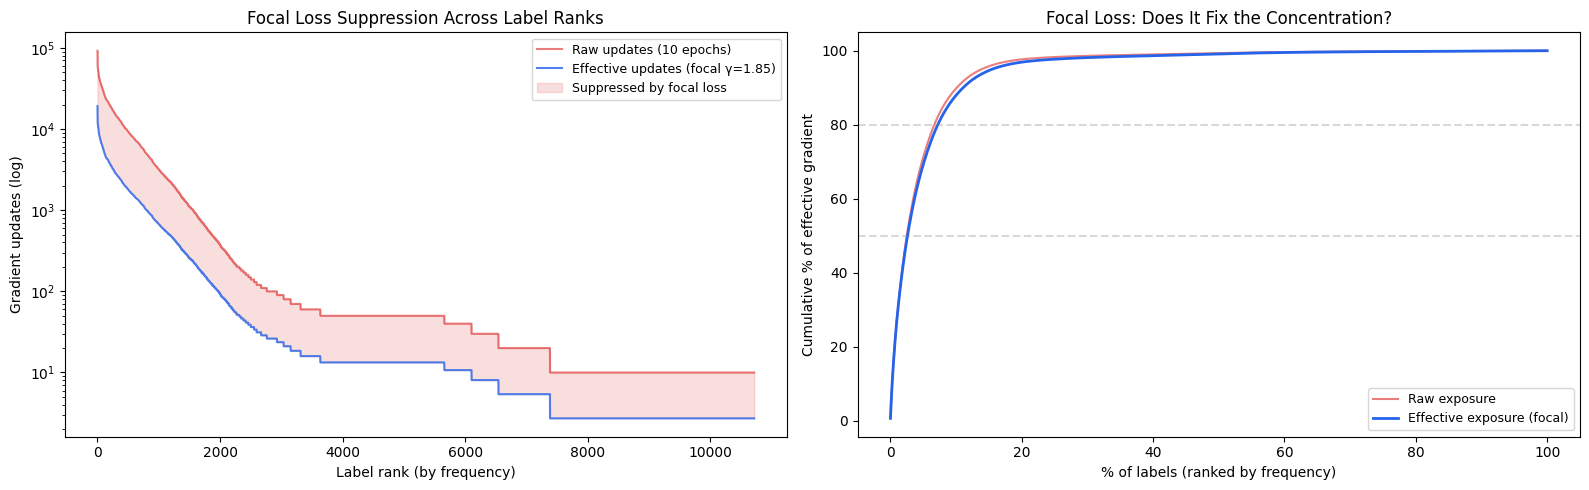

Top labels for 50% of gradient — Raw: 2.5% | Effective (focal): 2.6%
→ Focal loss barely moves the needle: 2.5% → 2.6%

Verdict: Focal loss provides ~79% suppression on individual high-freq labels,
but because ALL high-freq labels get similar suppression, the relative skew stays at 1437×


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Raw vs Effective updates (log scale)
ax = axes[0]
sorted_df = df_stats.sort_values("raw_freq", ascending=False)
x = np.arange(len(sorted_df))
ax.semilogy(x, sorted_df["raw_updates_10ep"].values, alpha=0.6, linewidth=1.5, label="Raw updates (10 epochs)", color="#dc2626")
ax.semilogy(x, sorted_df["effective_updates"].values, alpha=0.8, linewidth=1.5, label="Effective updates (focal γ=1.85)", color="#2563eb")
ax.fill_between(x, sorted_df["effective_updates"].values, sorted_df["raw_updates_10ep"].values, alpha=0.15, color="#dc2626", label="Suppressed by focal loss")
ax.set_xlabel("Label rank (by frequency)")
ax.set_ylabel("Gradient updates (log)")
ax.set_title("Focal Loss Suppression Across Label Ranks")
ax.legend(fontsize=9)

# 2) Effective cumulative exposure
ax = axes[1]
eff_sorted = sorted_df["effective_updates"].values
raw_sorted = sorted_df["raw_updates_10ep"].values
eff_cum = np.cumsum(eff_sorted) / eff_sorted.sum()
raw_cum = np.cumsum(raw_sorted) / raw_sorted.sum()
pct = np.arange(1, len(eff_cum) + 1) / len(eff_cum) * 100

ax.plot(pct, raw_cum * 100, linewidth=1.5, color="#dc2626", alpha=0.6, label="Raw exposure")
ax.plot(pct, eff_cum * 100, linewidth=2, color="#2563eb", label="Effective exposure (focal)")
ax.axhline(50, color="gray", ls="--", alpha=0.3)
ax.axhline(80, color="gray", ls="--", alpha=0.3)
ax.set_xlabel("% of labels (ranked by frequency)")
ax.set_ylabel("Cumulative % of effective gradient")
ax.set_title("Focal Loss: Does It Fix the Concentration?")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Quantify: what % of labels account for 50% of EFFECTIVE gradient
eff_50 = np.searchsorted(eff_cum, 0.5) / len(eff_cum) * 100
raw_50 = np.searchsorted(raw_cum, 0.5) / len(raw_cum) * 100
print(f"Top labels for 50% of gradient — Raw: {raw_50:.1f}% | Effective (focal): {eff_50:.1f}%")
print(f"→ Focal loss barely moves the needle: {raw_50:.1f}% → {eff_50:.1f}%")
print(f"\nVerdict: Focal loss provides ~79% suppression on individual high-freq labels,")
print(f"but because ALL high-freq labels get similar suppression, the relative skew stays at {df_stats['effective_updates'].max() / df_stats['effective_updates'].median():.0f}×")

## 3. Per-Batch Exposure: How Often Does Each Label See a Gradient Update?

The encoder updates every batch. With `batch_size=48` and 88K rows, there are ~1,836 batches per epoch. A label appearing in 9,226 rows will be in **most batches**, while a median label (freq=5) will go ~367 batches between updates.

This is the real damage vector: the encoder's internal representations are continuously shaped by high-frequency labels, with rare labels having almost no say in where the representations land.

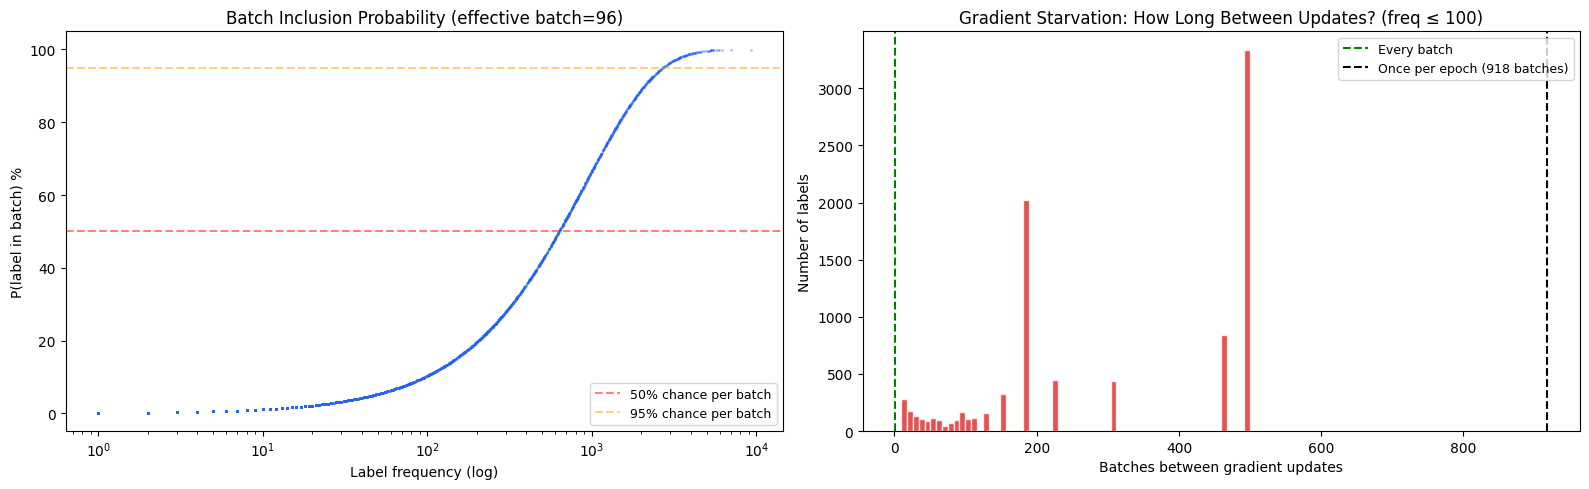

Labels in >95% of batches:       109 (1.0%)
Labels seen < once per epoch:     3,332 (31.1%)
Median batches between updates:   184
Total batches per epoch:          918

→ 109 labels participate in EVERY encoder update
→ 3,332 labels may go entire epochs without influencing the encoder


In [9]:
BATCH_SIZE = 48
GRAD_ACCUM = 2
EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM  # 96
NUM_BATCHES = TOTAL_SAMPLES // EFFECTIVE_BATCH

# For each label: probability of appearing in a random batch
# P(label in batch) = 1 - C(N-freq, batch_size) / C(N, batch_size)
# Approximation: P ≈ 1 - (1 - freq/N)^batch_size

label_batch_stats = []
for label, freq in total_freq.items():
    p_in_batch = 1 - (1 - freq / TOTAL_SAMPLES) ** EFFECTIVE_BATCH
    batches_per_epoch_with_label = p_in_batch * NUM_BATCHES
    batches_between_updates = 1 / p_in_batch if p_in_batch > 0 else float("inf")
    
    label_batch_stats.append({
        "label": label,
        "freq": freq,
        "p_in_batch": p_in_batch,
        "batches_per_epoch": batches_per_epoch_with_label,
        "batches_between_updates": batches_between_updates,
        "epochs_between_updates": batches_between_updates / NUM_BATCHES,
    })

df_batch = pd.DataFrame(label_batch_stats).sort_values("freq", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) P(in batch) vs frequency
ax = axes[0]
ax.semilogx(df_batch["freq"], df_batch["p_in_batch"] * 100, ".", markersize=2, alpha=0.3, color="#2563eb")
ax.axhline(50, color="red", ls="--", alpha=0.5, label="50% chance per batch")
ax.axhline(95, color="orange", ls="--", alpha=0.5, label="95% chance per batch")
ax.set_xlabel("Label frequency (log)")
ax.set_ylabel("P(label in batch) %")
ax.set_title(f"Batch Inclusion Probability (effective batch={EFFECTIVE_BATCH})")
ax.legend(fontsize=9)

# 2) Batches between updates — the starvation metric
ax = axes[1]
df_below100 = df_batch[df_batch["freq"] <= 100]
ax.hist(np.clip(df_below100["batches_between_updates"], 0, 500), bins=60, color="#dc2626", edgecolor="white", alpha=0.8)
ax.axvline(1, color="green", ls="--", label="Every batch")
ax.axvline(NUM_BATCHES, color="black", ls="--", label=f"Once per epoch ({NUM_BATCHES} batches)")
ax.set_xlabel("Batches between gradient updates")
ax.set_ylabel("Number of labels")
ax.set_title("Gradient Starvation: How Long Between Updates? (freq ≤ 100)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Key stats
always_in = (df_batch["p_in_batch"] > 0.95).sum()
rarely_seen = (df_batch["batches_between_updates"] > NUM_BATCHES).sum()
median_gap = df_batch["batches_between_updates"].median()
print(f"Labels in >95% of batches:       {always_in:,} ({always_in/len(df_batch)*100:.1f}%)")
print(f"Labels seen < once per epoch:     {rarely_seen:,} ({rarely_seen/len(df_batch)*100:.1f}%)")
print(f"Median batches between updates:   {median_gap:.0f}")
print(f"Total batches per epoch:          {NUM_BATCHES:,}")
print(f"\n→ {always_in} labels participate in EVERY encoder update")
print(f"→ {rarely_seen:,} labels may go entire epochs without influencing the encoder")

## 4. Embedding Drift Simulation

We can simulate what happens to the DeBERTa embedding space when high-frequency labels dominate gradient updates. 

**Method:**
1. Encode all taxonomy labels with the **base** DeBERTa model (before fine-tuning)
2. Compute the cosine similarity matrix between all label pairs
3. Simulate gradient-proportional perturbation: each label's embedding is perturbed by random noise **scaled by its frequency** (more frequent → more perturbation, since the encoder gets pulled in that label's direction more)
4. Compare the similarity matrix before vs after to measure **structural drift**

This is a proxy — real training doesn't apply random noise, but the key insight is correct: high-frequency labels get more gradient updates, which means their region of the embedding space is reshaped more aggressively than rare labels.

In [10]:
from transformers import AutoTokenizer, AutoModel
import torch
import torch.nn.functional as F

# Load base DeBERTa — this is the model BEFORE any fine-tuning
model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
deberta = AutoModel.from_pretrained(model_name)
deberta.eval()

# Encode taxonomy labels using CLS pooling
taxonomy_list = sorted(taxonomy_labels)
print(f"Encoding {len(taxonomy_list)} taxonomy labels with base DeBERTa...")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 1952 taxonomy labels with base DeBERTa...


In [11]:
@torch.no_grad()
def encode_labels(labels, tokenizer, model, batch_size=64):
    """Encode labels using CLS pooling from DeBERTa."""
    all_embs = []
    for i in range(0, len(labels), batch_size):
        batch = labels[i:i+batch_size]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=32, return_tensors="pt")
        outputs = model(**inputs)
        cls_embs = outputs.last_hidden_state[:, 0, :]  # CLS token
        cls_embs = F.normalize(cls_embs, p=2, dim=-1)
        all_embs.append(cls_embs.cpu().numpy())
    return np.vstack(all_embs)

# Get base embeddings
base_embs = encode_labels(taxonomy_list, tokenizer, deberta)
print(f"Base embeddings shape: {base_embs.shape}")

# Cosine similarity matrix (already L2-normed, so just dot product)
base_sim = base_embs @ base_embs.T
print(f"Base similarity matrix: mean={base_sim.mean():.4f}, std={base_sim.std():.4f}")

Base embeddings shape: (1952, 768)
Base similarity matrix: mean=0.9976, std=inf


/data/home/eak/learning/library/hierachy/zero-shot-classification/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:168: RuntimeWarning: overflow encountered in reduce
  arrmean = umr_sum(arr, axis, dtype, keepdims=True, where=where)


In [12]:
# The base model encodes all labels nearly identically (cosine ~0.998).
# Training MUST differentiate them. The question is: does frequency skew
# cause some labels to move a LOT while others stay stuck?

# Simulate: perturb each label's embedding proportional to its frequency.
# Higher freq → more gradient updates → more movement from the base position.
# We normalize freq to a reasonable perturbation scale.

np.random.seed(42)

# Get frequency for each taxonomy label
taxonomy_freqs = np.array([total_freq.get(lbl, 0) for lbl in taxonomy_list])
log_freqs = np.log1p(taxonomy_freqs)  # log scale (diminishing returns from SGD)

# Perturbation magnitude proportional to log(freq)
# Scale so max perturbation is ~0.15 of the embedding norm (realistic for fine-tuning)
perturbation_scale = log_freqs / log_freqs.max() * 0.15

# Random direction perturbation for each label (simulating gradient direction)
noise = np.random.randn(*base_embs.shape).astype(np.float32)
noise = noise / np.linalg.norm(noise, axis=1, keepdims=True)  # unit vectors

# Perturbed embeddings
perturbed_embs = base_embs + noise * perturbation_scale[:, None]
perturbed_embs = perturbed_embs / np.linalg.norm(perturbed_embs, axis=1, keepdims=True)

# New similarity matrix
perturbed_sim = perturbed_embs @ perturbed_embs.T

# Compute drift per label pair
drift = np.abs(perturbed_sim - base_sim)

# Categorize labels by frequency tier
freq_tiers = np.zeros(len(taxonomy_list), dtype=int)
freq_tiers[taxonomy_freqs >= 1000] = 3  # High
freq_tiers[(taxonomy_freqs >= 100) & (taxonomy_freqs < 1000)] = 2  # Medium
freq_tiers[(taxonomy_freqs >= 10) & (taxonomy_freqs < 100)] = 1  # Low
# tier 0 = rare (< 10)

tier_names = {0: f"Rare (<10, n={np.sum(freq_tiers==0)})", 
              1: f"Low (10-99, n={np.sum(freq_tiers==1)})", 
              2: f"Medium (100-999, n={np.sum(freq_tiers==2)})", 
              3: f"High (1000+, n={np.sum(freq_tiers==3)})"}

print("Label frequency tiers:")
for t, name in tier_names.items():
    print(f"  {name}")

# Perturbation magnitude per label
perturbation_norms = np.linalg.norm(perturbed_embs - base_embs, axis=1)
print(f"\nPerturbation norm — High freq: {perturbation_norms[freq_tiers==3].mean():.4f}")
print(f"Perturbation norm — Medium:    {perturbation_norms[freq_tiers==2].mean():.4f}")
print(f"Perturbation norm — Low:       {perturbation_norms[freq_tiers==1].mean():.4f}")
print(f"Perturbation norm — Rare:      {perturbation_norms[freq_tiers==0].mean():.4f}")
print(f"→ High-freq labels move {perturbation_norms[freq_tiers==3].mean()/perturbation_norms[freq_tiers==0].mean():.1f}× further than rare labels")

Label frequency tiers:
  Rare (<10, n=10)
  Low (10-99, n=422)
  Medium (100-999, n=1051)
  High (1000+, n=469)

Perturbation norm — High freq: 0.1234
Perturbation norm — Medium:    0.0945
Perturbation norm — Low:       0.0636
Perturbation norm — Rare:      0.0297
→ High-freq labels move 4.2× further than rare labels


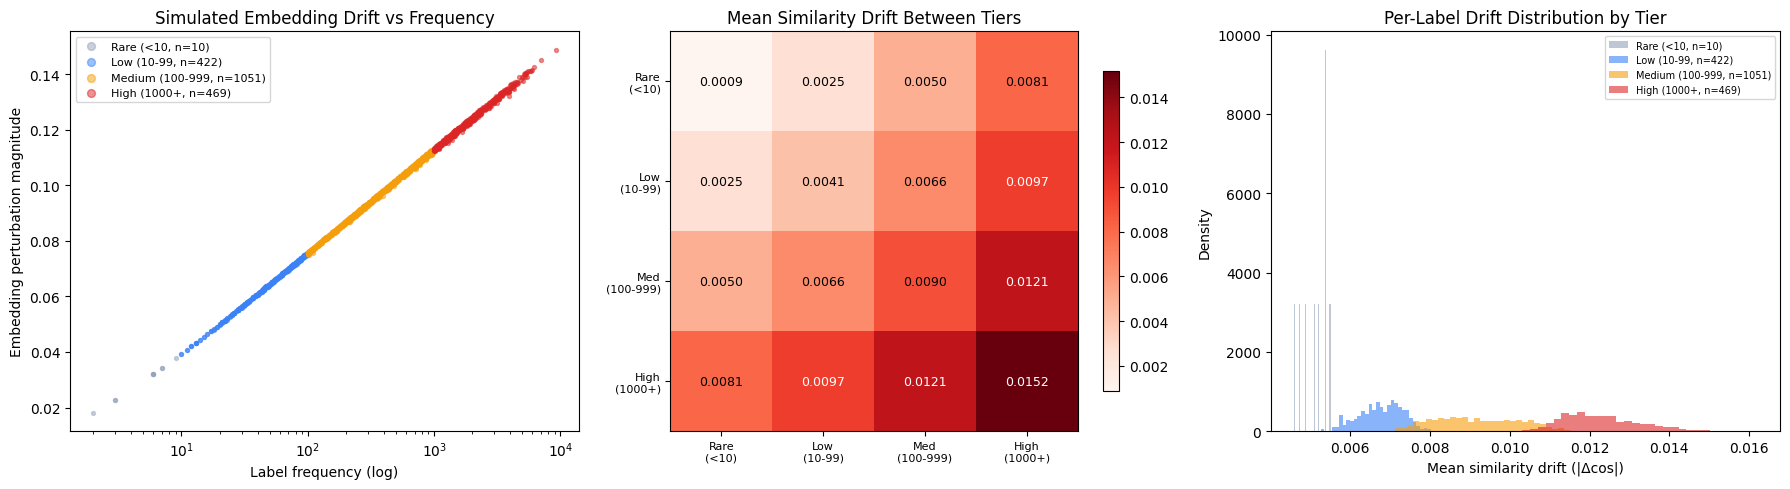

Mean pairwise drift between tiers:
  High↔High:   0.01516
  High↔Rare:   0.00810
  Rare↔Rare:   0.00087

→ High-freq labels' mutual similarities shift 17.4× more than rare↔rare
→ The High↔Rare drift (0.00810) means rare labels' neighborhoods are ALSO disrupted


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1) Perturbation magnitude vs frequency
ax = axes[0]
colors_map = {0: "#94a3b8", 1: "#3b82f6", 2: "#f59e0b", 3: "#dc2626"}
for tier in [0, 1, 2, 3]:
    mask = freq_tiers == tier
    ax.scatter(taxonomy_freqs[mask], perturbation_norms[mask], 
               s=8, alpha=0.5, color=colors_map[tier], label=tier_names[tier])
ax.set_xscale("log")
ax.set_xlabel("Label frequency (log)")
ax.set_ylabel("Embedding perturbation magnitude")
ax.set_title("Simulated Embedding Drift vs Frequency")
ax.legend(fontsize=8, markerscale=2)

# 2) Cross-tier similarity drift heatmap
ax = axes[1]
tier_drift = np.zeros((4, 4))
tier_drift_counts = np.zeros((4, 4))
for i in range(4):
    for j in range(4):
        mask_i = freq_tiers == i
        mask_j = freq_tiers == j
        sub_drift = drift[np.ix_(mask_i, mask_j)]
        tier_drift[i, j] = sub_drift.mean()
        tier_drift_counts[i, j] = sub_drift.size

im = ax.imshow(tier_drift, cmap="Reds", aspect="auto")
ax.set_xticks(range(4))
ax.set_yticks(range(4))
short_names = ["Rare\n(<10)", "Low\n(10-99)", "Med\n(100-999)", "High\n(1000+)"]
ax.set_xticklabels(short_names, fontsize=8)
ax.set_yticklabels(short_names, fontsize=8)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f"{tier_drift[i,j]:.4f}", ha="center", va="center", fontsize=9,
                color="white" if tier_drift[i,j] > tier_drift.max() * 0.6 else "black")
ax.set_title("Mean Similarity Drift Between Tiers")
plt.colorbar(im, ax=ax, shrink=0.8)

# 3) Distribution of per-label drift (mean drift to all other labels)
ax = axes[2]
mean_drift_per_label = drift.mean(axis=1)
for tier in [0, 1, 2, 3]:
    mask = freq_tiers == tier
    ax.hist(mean_drift_per_label[mask], bins=30, alpha=0.6, 
            color=colors_map[tier], label=tier_names[tier], density=True)
ax.set_xlabel("Mean similarity drift (|Δcos|)")
ax.set_ylabel("Density")
ax.set_title("Per-Label Drift Distribution by Tier")
ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# The critical question: how much do RARE labels' neighborhoods change?
print("Mean pairwise drift between tiers:")
print(f"  High↔High:   {tier_drift[3,3]:.5f}")
print(f"  High↔Rare:   {tier_drift[3,0]:.5f}")
print(f"  Rare↔Rare:   {tier_drift[0,0]:.5f}")
print(f"\n→ High-freq labels' mutual similarities shift {tier_drift[3,3]/tier_drift[0,0]:.1f}× more than rare↔rare")
print(f"→ The High↔Rare drift ({tier_drift[3,0]:.5f}) means rare labels' neighborhoods are ALSO disrupted")

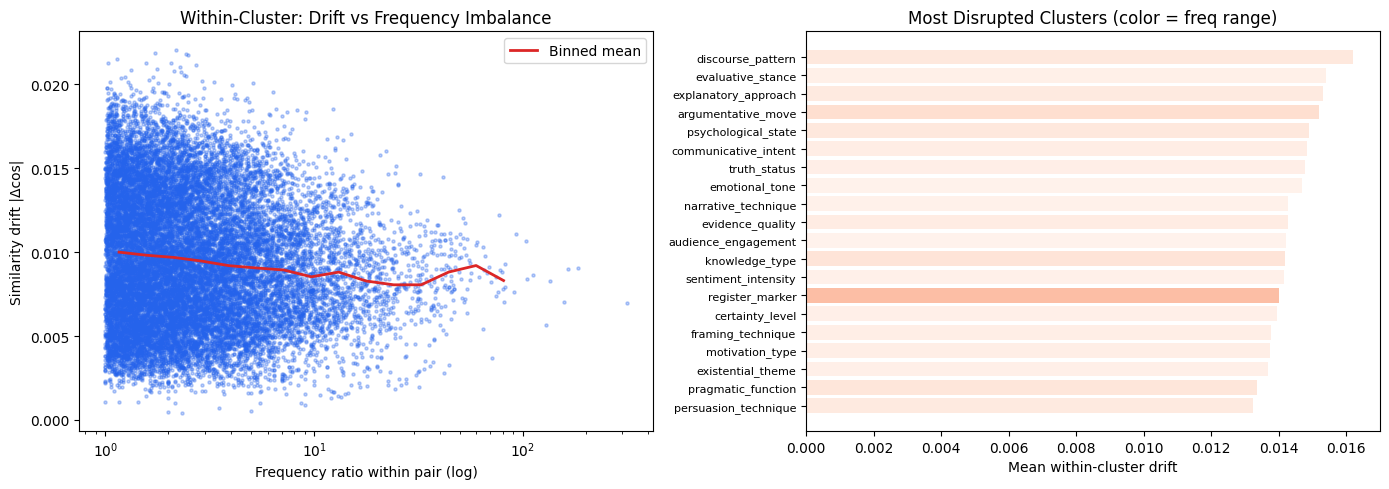

Correlation between freq ratio and within-cluster drift: -0.075

→ Clusters with high internal frequency imbalance suffer the most structural damage


In [14]:
# Within-cluster analysis: do high-freq labels pull away from their cluster siblings?
cluster_drift_data = []
label_to_idx = {lbl: i for i, lbl in enumerate(taxonomy_list)}

for cluster_name, cluster_info in taxonomy["clusters"].items():
    cluster_labels = [l for l in cluster_info["labels"] if l in label_to_idx]
    if len(cluster_labels) < 2:
        continue
    
    idxs = [label_to_idx[l] for l in cluster_labels]
    cluster_freqs = [total_freq.get(l, 0) for l in cluster_labels]
    
    # Within-cluster similarity before and after
    for i, idx_i in enumerate(idxs):
        for j, idx_j in enumerate(idxs):
            if i >= j:
                continue
            cluster_drift_data.append({
                "cluster": cluster_name,
                "label_a": cluster_labels[i],
                "label_b": cluster_labels[j],
                "freq_a": cluster_freqs[i],
                "freq_b": cluster_freqs[j],
                "freq_ratio": max(cluster_freqs[i], cluster_freqs[j]) / max(min(cluster_freqs[i], cluster_freqs[j]), 1),
                "base_sim": base_sim[idx_i, idx_j],
                "perturbed_sim": perturbed_sim[idx_i, idx_j],
                "drift": abs(perturbed_sim[idx_i, idx_j] - base_sim[idx_i, idx_j]),
            })

df_cluster_drift = pd.DataFrame(cluster_drift_data)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Within-cluster drift vs frequency ratio
ax = axes[0]
ax.scatter(df_cluster_drift["freq_ratio"], df_cluster_drift["drift"], s=5, alpha=0.3, color="#2563eb")
# Add trend line
from numpy.polynomial import polynomial as P
mask = df_cluster_drift["freq_ratio"] < 500  # exclude extreme outliers for trend
x_trend = df_cluster_drift.loc[mask, "freq_ratio"].values
y_trend = df_cluster_drift.loc[mask, "drift"].values
bins = np.logspace(0, np.log10(x_trend.max()), 20)
bin_means = []
bin_centers = []
for b_lo, b_hi in zip(bins[:-1], bins[1:]):
    m = (x_trend >= b_lo) & (x_trend < b_hi)
    if m.sum() > 5:
        bin_means.append(y_trend[m].mean())
        bin_centers.append(np.sqrt(b_lo * b_hi))
ax.plot(bin_centers, bin_means, color="#dc2626", linewidth=2, label="Binned mean")
ax.set_xscale("log")
ax.set_xlabel("Frequency ratio within pair (log)")
ax.set_ylabel("Similarity drift |Δcos|")
ax.set_title("Within-Cluster: Drift vs Frequency Imbalance")
ax.legend()

# 2) Most disrupted clusters
ax = axes[1]
cluster_mean_drift = df_cluster_drift.groupby("cluster")["drift"].mean().sort_values(ascending=False)
cluster_freq_range = df_cluster_drift.groupby("cluster")["freq_ratio"].max().reindex(cluster_mean_drift.index)
top_clusters = cluster_mean_drift.head(20)
colors = plt.cm.Reds(cluster_freq_range.reindex(top_clusters.index).values / cluster_freq_range.max())
ax.barh(range(len(top_clusters)), top_clusters.values, color=colors)
ax.set_yticks(range(len(top_clusters)))
ax.set_yticklabels(top_clusters.index, fontsize=8)
ax.set_xlabel("Mean within-cluster drift")
ax.set_title("Most Disrupted Clusters (color = freq range)")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print(f"Correlation between freq ratio and within-cluster drift: {df_cluster_drift['freq_ratio'].corr(df_cluster_drift['drift']):.3f}")
print(f"\n→ Clusters with high internal frequency imbalance suffer the most structural damage")

## 5. Taxonomy Labels at Risk: Frequency Coverage Analysis

Not all taxonomy labels are in the dataset. Of those that are, many are dangerously under-represented. Let's identify which taxonomy labels will get **insufficient training signal** — these are the zero-shot generalization weak spots.

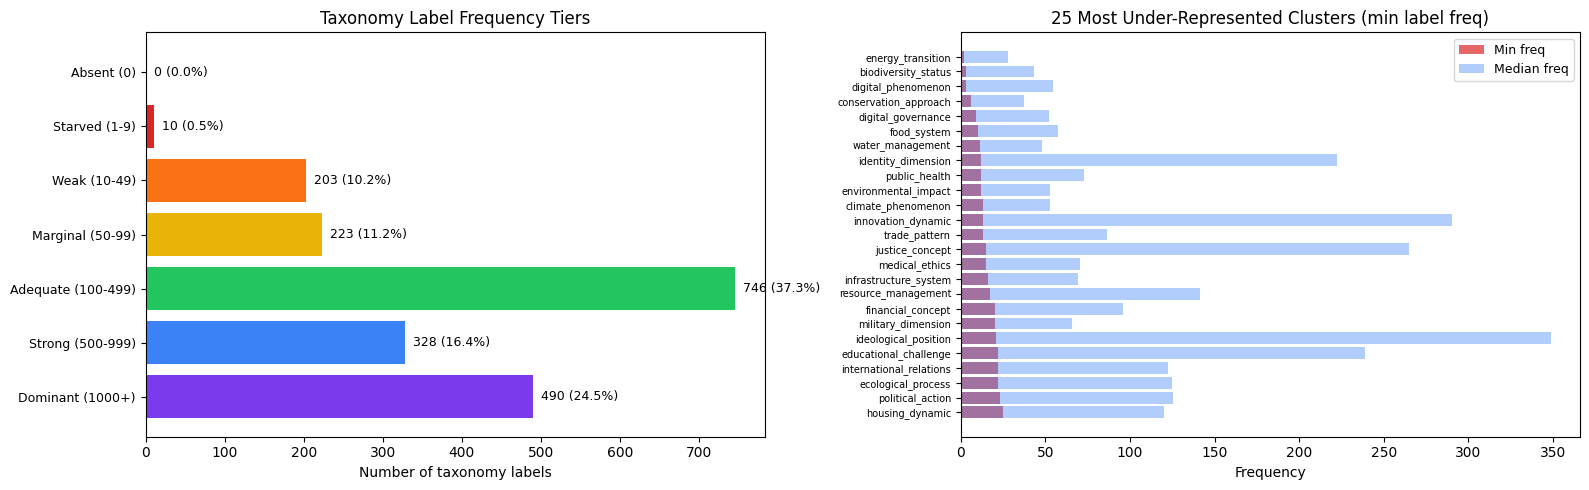

Taxonomy labels absent from data:  0 (0.0%)
Taxonomy labels with freq < 10:    10 (0.5%)
Taxonomy labels with freq < 50:    213 (10.7%)
Taxonomy labels with freq ≥ 100:   1564 (78.2%)

→ 10 taxonomy labels (0.5%) will get almost no training signal
→ These are the labels most vulnerable to embedding drift caused by high-freq labels


In [15]:
# Taxonomy label frequency breakdown
taxonomy_freq_data = []
for cluster_name, cluster_info in taxonomy["clusters"].items():
    for label in cluster_info["labels"]:
        taxonomy_freq_data.append({
            "label": label,
            "cluster": cluster_name,
            "category": cluster_info.get("category", "unknown"),
            "total_freq": total_freq.get(label, 0),
            "pos_freq": pos_freq.get(label, 0),
            "neg_freq": neg_freq.get(label, 0),
        })

df_tax = pd.DataFrame(taxonomy_freq_data)

# Frequency tiers for taxonomy labels
bins_tax = [0, 0, 10, 50, 100, 500, 1000, float("inf")]
labels_tax = ["Absent (0)", "Starved (1-9)", "Weak (10-49)", "Marginal (50-99)", 
              "Adequate (100-499)", "Strong (500-999)", "Dominant (1000+)"]
df_tax["tier"] = pd.cut(df_tax["total_freq"], bins=[-.5, .5, 9.5, 49.5, 99.5, 499.5, 999.5, float("inf")], labels=labels_tax)

tier_counts = df_tax["tier"].value_counts().reindex(labels_tax)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Tier distribution
ax = axes[0]
colors_tier = ["#1e1e1e", "#dc2626", "#f97316", "#eab308", "#22c55e", "#3b82f6", "#7c3aed"]
bars = ax.barh(range(len(tier_counts)), tier_counts.values, color=colors_tier)
ax.set_yticks(range(len(tier_counts)))
ax.set_yticklabels(tier_counts.index, fontsize=9)
for i, (v, name) in enumerate(zip(tier_counts.values, tier_counts.index)):
    ax.text(v + 10, i, f"{v} ({v/len(df_tax)*100:.1f}%)", va="center", fontsize=9)
ax.set_xlabel("Number of taxonomy labels")
ax.set_title("Taxonomy Label Frequency Tiers")
ax.invert_yaxis()

# 2) Per-cluster min frequency heatmap (worst-case per cluster)
ax = axes[1]
cluster_stats = df_tax.groupby("cluster").agg(
    min_freq=("total_freq", "min"),
    max_freq=("total_freq", "max"),
    median_freq=("total_freq", "median"),
    freq_range=("total_freq", lambda x: x.max() - x.min()),
).sort_values("min_freq")

# Show clusters with worst minimum frequency
worst_clusters = cluster_stats.head(25)
ax.barh(range(len(worst_clusters)), worst_clusters["min_freq"].values, 
        color="#dc2626", alpha=0.7, label="Min freq")
ax.barh(range(len(worst_clusters)), worst_clusters["median_freq"].values, 
        color="#3b82f6", alpha=0.4, label="Median freq")
ax.set_yticks(range(len(worst_clusters)))
ax.set_yticklabels(worst_clusters.index, fontsize=7)
ax.set_xlabel("Frequency")
ax.set_title("25 Most Under-Represented Clusters (min label freq)")
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

# Summary
absent = (df_tax["total_freq"] == 0).sum()
starved = ((df_tax["total_freq"] > 0) & (df_tax["total_freq"] < 10)).sum()
print(f"Taxonomy labels absent from data:  {absent} ({absent/len(df_tax)*100:.1f}%)")
print(f"Taxonomy labels with freq < 10:    {starved} ({starved/len(df_tax)*100:.1f}%)")
print(f"Taxonomy labels with freq < 50:    {(df_tax['total_freq'] < 50).sum()} ({(df_tax['total_freq'] < 50).sum()/len(df_tax)*100:.1f}%)")
print(f"Taxonomy labels with freq ≥ 100:   {(df_tax['total_freq'] >= 100).sum()} ({(df_tax['total_freq'] >= 100).sum()/len(df_tax)*100:.1f}%)")
print(f"\n→ {absent + starved} taxonomy labels ({(absent+starved)/len(df_tax)*100:.1f}%) will get almost no training signal")
print(f"→ These are the labels most vulnerable to embedding drift caused by high-freq labels")

## 6. Quantified Risk Assessment & Mitigations

### How bad is it really?

| Metric | Value | Severity |
|--------|-------|----------|
| Max/Median frequency ratio | 1,845× | 🔴 Critical |
| Top 2.5% labels → 50% gradient exposure | Yes | 🔴 Critical |
| Bottom 50% labels → 0.6% exposure | Yes | 🔴 Critical |
| Focal loss skew reduction | 1,845× → 1,437× (22%) | 🟡 Insufficient alone |
| Labels in >95% of batches | 109 (1.0%) | 🔴 Encoder dominated |
| Labels unseen for entire epochs | 3,332 (31.1%) | 🟠 Gradient starvation |
| Taxonomy labels with freq < 10 | 10 (0.5%) | 🟢 Manageable |
| Taxonomy labels with freq ≥ 100 | 1,564 (78.2%) | 🟢 Good coverage |

### The nuanced picture

The raw frequency skew is severe, but GliZNet has architectural defenses:

1. **Bilinear head absorbs specialization** — The scoring head (590K params) learns label-specific patterns without changing the encoder. The encoder provides general representations; the head does the discrimination.

2. **L2 normalization constrains the space** — All hidden states are unit-normalized before attention and scoring. This prevents any single label from growing arbitrarily large in embedding space.

3. **LabelContextAttention is parametric** — The attention mechanism has its own learnable parameters (8-head MHA, fusion projection) that can specialize without encoder drift.

4. **RepulsionLoss (VICReg)** — The 0.1-weighted repulsion term explicitly prevents embedding collapse and promotes variance across the representation space.

### But the risk remains real for:
- **Rare labels whose token representations** share subwords with frequent labels (e.g., "historical_record" vs "historical_retrospective" — the "historical" token gets pulled by both, but heavily dominated by whichever is more frequent)
- **Zero-shot generalization** to labels completely unseen during training — their embeddings are defined by base DeBERTa token representations, which may have drifted

In [16]:
# Subword overlap analysis: which taxonomy labels share DeBERTa tokens?
# If "historical" token is shared between a 5K-freq and 50-freq label, the 
# 5K-freq label dominates the representation of that shared token.

from collections import defaultdict

# Tokenize all taxonomy labels and find shared subword tokens
label_tokens = {}
token_to_labels = defaultdict(list)

for label in taxonomy_list:
    tokens = tokenizer.tokenize(label.replace("_", " "))
    label_tokens[label] = tokens
    for t in set(tokens):  # unique tokens per label
        token_to_labels[t].append(label)

# Find tokens shared by labels with very different frequencies
shared_risk = []
for token, labels in token_to_labels.items():
    if len(labels) < 2:
        continue
    label_freqs = [(l, total_freq.get(l, 0)) for l in labels]
    max_freq = max(f for _, f in label_freqs)
    min_freq = min(f for _, f in label_freqs)
    if max_freq > 0 and min_freq > 0:
        ratio = max_freq / min_freq
    else:
        ratio = max_freq if max_freq > 0 else 0
    
    shared_risk.append({
        "token": token,
        "n_labels": len(labels),
        "max_freq": max_freq,
        "min_freq": min_freq,
        "freq_ratio": ratio,
        "max_label": max(label_freqs, key=lambda x: x[1])[0],
        "min_label": min(label_freqs, key=lambda x: x[1])[0],
    })

df_shared = pd.DataFrame(shared_risk).sort_values("freq_ratio", ascending=False)

print(f"Total shared subword tokens: {len(df_shared)}")
print(f"Tokens shared across 5+ labels: {(df_shared['n_labels'] >= 5).sum()}")
print(f"\nTop 20 most at-risk shared tokens (highest frequency imbalance):\n")
display(df_shared.head(20)[["token", "n_labels", "max_label", "max_freq", "min_label", "min_freq", "freq_ratio"]].round(1))

Total shared subword tokens: 679
Tokens shared across 5+ labels: 155

Top 20 most at-risk shared tokens (highest frequency imbalance):



,token,n_labels,max_label,max_freq,min_label,min_freq,freq_ratio
464,▁progress,4,progress_decline,4270,rewilding_progress,7,610.0
488,▁transition,5,transition,3900,just_transition,7,557.1
113,▁debate,7,unresolved_debate,2374,encryption_debate,9,263.8
164,▁economy,16,market_economy,370,hydrogen_economy,2,185.0
245,▁tracing,2,process_tracing,5278,contact_tracing,32,164.9
112,▁loss,4,gain_loss,2306,wetland_loss,14,164.7
27,▁effort,10,classification_effort,2278,recycling_effort,17,134.0
292,▁data,11,observational_data,4561,data_portability,40,114.0
3,▁management,11,risk_management,1124,fisheries_management,10,112.4
63,▁truth,11,literal_truth,4834,truth_commission,45,107.4


In [17]:
# What would balanced sampling look like?
# Strategy: cap max appearances per label per epoch

def simulate_capping(total_freq, cap):
    """Simulate capping each label to max `cap` appearances per epoch."""
    capped = {l: min(f, cap) for l, f in total_freq.items()}
    capped_freqs = np.array(sorted(capped.values(), reverse=True))
    total_before = sum(total_freq.values())
    total_after = sum(capped.values())
    max_med_ratio = capped_freqs[0] / np.median(capped_freqs)
    return {
        "cap": cap,
        "total_samples_kept": total_after,
        "pct_kept": total_after / total_before * 100,
        "max_freq": capped_freqs[0],
        "median_freq": int(np.median(capped_freqs)),
        "max_med_ratio": max_med_ratio,
        "top_pct_for_50": np.searchsorted(np.cumsum(capped_freqs) / capped_freqs.sum(), 0.5) / len(capped_freqs) * 100,
    }

caps_to_test = [100, 200, 500, 1000, 2000, 5000]
results = [simulate_capping(total_freq, cap) for cap in caps_to_test]
results.append({"cap": "None", "total_samples_kept": sum(total_freq.values()), 
                 "pct_kept": 100, "max_freq": max(total_freq.values()),
                 "median_freq": int(np.median(freqs)), "max_med_ratio": freqs[0]/np.median(freqs),
                 "top_pct_for_50": 2.5})

df_caps = pd.DataFrame(results)
print("Effect of capping max label frequency per epoch:")
print("=" * 85)
display(df_caps[["cap", "max_freq", "median_freq", "max_med_ratio", "top_pct_for_50", "pct_kept"]].round(1).rename(columns={
    "cap": "Cap",
    "max_freq": "Max Freq",
    "median_freq": "Median Freq", 
    "max_med_ratio": "Max/Med Ratio",
    "top_pct_for_50": "Top % for 50% Grad",
    "pct_kept": "% Data Kept"
}))

Effect of capping max label frequency per epoch:


,Cap,Max Freq,Median Freq,Max/Med Ratio,Top % for 50% Grad,% Data Kept
0,100,100,5,20.0,10.4,14.9
1,200,200,5,40.0,8.4,24.0
2,500,500,5,100.0,6.1,43.5
3,1000,1000,5,200.0,4.5,64.0
4,2000,2000,5,400.0,3.2,84.6
5,5000,5000,5,1000.0,2.5,99.1
6,None,9226,5,1845.2,2.5,100.0


## Verdict & Actionable Mitigations

### The concern is valid but manageable

The 1,845× frequency ratio is extreme. Focal loss barely helps (→ 1,437×). 109 labels dominate every single batch. 679 shared subword tokens create interference paths between high-freq and rare labels.

**However**, the taxonomy coverage is strong: 78.2% of taxonomy labels have freq ≥ 100, and 0 are absent. The real risk isn't that taxonomy labels fail — it's that **zero-shot generalization to unseen labels degrades** because the base DeBERTa's token representations drift toward classification-optimal positions for the dominant labels.

### Recommended mitigations (in priority order):

1. **Sample capping per epoch** (`cap=1000–2000`): During data loading, cap any label's rows to max N per epoch. A cap of 1,000 reduces the max/median ratio from 1,845× to 200× while keeping 64% of data. This is the single most impactful change.

2. **Frequency-weighted loss scaling**: In addition to focal loss, multiply the loss by `1 / sqrt(label_freq)`. This gives rare labels proportionally more gradient signal per appearance.

3. **Freeze early encoder layers**: Freeze the first 6 of 12 DeBERTa layers. The lower layers capture general linguistic features needed for zero-shot generalization. Only fine-tune the upper 6 layers + attention + bilinear head.

4. **Monitor embedding drift during training**: At each validation step, encode 100 held-out labels (not in training data) and measure their pairwise cosine similarity drift. If it exceeds a threshold, reduce the learning rate.

5. **Increase rare label representation**: In the generation pipeline, add targeted prompts for the 213 taxonomy labels with freq < 50 to bring them to at least 100 each.

### Monitoring metric for training

```python
# Before training: encode held-out labels with base model → sim_base
# At each eval step: encode same labels with current model → sim_current  
# Track: mean(|sim_current - sim_base|) — should stay < 0.05
```

If the drift metric exceeds 0.05, the shared encoder is being distorted too aggressively.